<a href="https://colab.research.google.com/github/satyaki102/testrepo/blob/main/Calculation_of_house_pricing_using_Random_Forest_and_XGBoost_modeling_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import time

In [2]:
data = fetch_california_housing()
x, y = data.data, data.target


In [3]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [ ]:
N_observations, N_features = x.shape
print('Number of Observations:'+str(N_observations))
print('Number of Features:' +str(N_features))

Number of Observations:20640
Number of Features:8


**Initialize models**

In this step you define the number of base estimators, or individual trees, to be used in each model, and then intialize models for Random Forest regression and XGBoost regression. You'll just use the default parameters to make the performance comparisons. As a part of the performance comparison, we'll also measure the training times for both models.

In [ ]:
n_estimators = 100
rf = RandomForestRegressor(n_estimators = n_estimators, random_state = 42)
xgb = XGBRegressor(n_estimators = n_estimators, random_state = 42)

In [ ]:
# Fit models
# Measure training time for Random Forest
start_time_rf = time.time()
rf.fit(x_train,y_train)
end_time_rf = time.time()
rf_train_time = end_time_rf - start_time_rf

# Measure training time for XGBoost

start_time_xgb = time.time()
xgb.fit(x_train,y_train)
end_time_xgb = time.time()
xgb_train_time = end_time_xgb - start_time_xgb

print(rf_train_time)
print(xgb_train_time)

21.076976537704468
0.4371631145477295


**Exercise 2. Use the fitted models to make predictions on the test set.**

Also, measure the time it takes for each model to make its predictions using the time.time() function to measure the times before and after each model prediction.

In [ ]:
start_time_rf = time.time()
y_pred_rf = rf.predict(x_test)
end_time_rf = time.time()
rf_pred_time = end_time_rf - start_time_rf

start_time_xgb = time.time()
y_pred_xgb = xgb.predict(x_test)
end_time_rf = time.time()
xgb_pred_time = end_time_rf - start_time_rf

print(rf_pred_time)
print(xgb_pred_time)

0.1549851894378662
0.16436553001403809


**Exercise 3: Calulate the MSE and R^2 values for both models**

In [ ]:
mse_rf = mean_squared_error(y_test,y_pred_rf)
mse_xgb = mean_squared_error(y_test,y_pred_xgb)
r2_rf = r2_score(y_test,y_pred_rf)
r2_xgb = r2_score(y_test,y_pred_xgb)

In [ ]:
print(mse_rf)
print(mse_xgb)
print(r2_rf)
print(r2_xgb)

0.2553684927247781
0.2225899267544737
0.8051230593157366
0.8301370561019205


**Exercise 6. Calculate the standard deviation of the test data**


In [ ]:
std_y = np.std(y_test)

**Visualize the results**

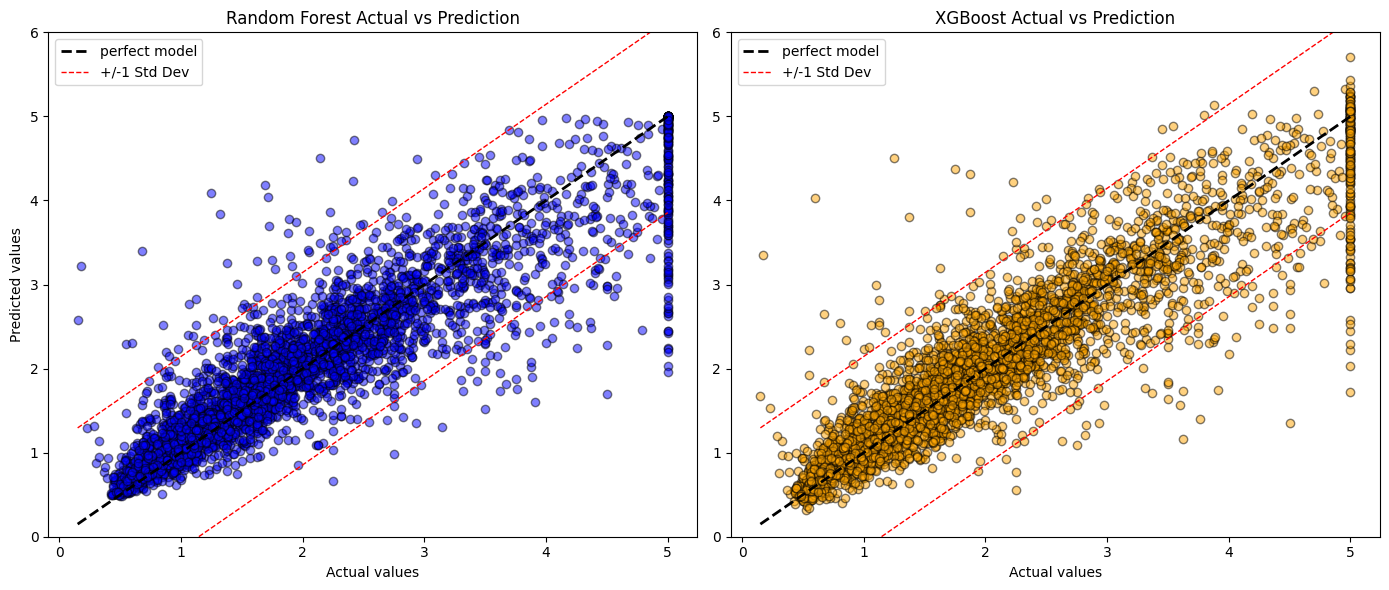

In [ ]:
plt.figure(figsize = (14,6))

#Random Forest plot
plt.subplot(1,2,1)
plt.scatter(y_test,y_pred_rf,alpha = 0.5, color = 'blue', ec = 'k')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()], 'k--',lw=2, label='perfect model')
plt.plot([y_test.min(),y_test.max()],[y_test.min() + std_y, y_test.max() + std_y],'r--', lw=1,label = '+/-1 Std Dev')
plt.plot([y_test.min(),y_test.max()],[y_test.min() - std_y, y_test.max() - std_y],'r--', lw=1)
plt.ylim(0,6)
plt.title('Random Forest Actual vs Prediction')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.legend()

#XGBoost
plt.subplot(1,2,2)
plt.scatter(y_test,y_pred_xgb,alpha = 0.5, color = 'orange', ec = 'k')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()], 'k--',lw=2, label='perfect model')
plt.plot([y_test.min(),y_test.max()],[y_test.min() + std_y, y_test.max() + std_y],'r--', lw=1,label = '+/-1 Std Dev')
plt.plot([y_test.min(),y_test.max()],[y_test.min() - std_y, y_test.max() - std_y],'r--', lw=1)
plt.ylim(0,6)
plt.title('XGBoost Actual vs Prediction')
plt.xlabel('Actual values')
#plt.ylabel('Predicted values')
plt.legend()
plt.tight_layout()
plt.show()



Both models performed very well. Most of their predictions fall within a standard deviation of the target. Interestingly, random forest "respects" the upper bound (the maximum value) present in the target by staying within its limits, while XGBoost "overshoots", or exceeds this limit.